# 🧮 unitary
**Obtiene y visualiza la matriz unitaria de un circuito cuántico.**

Usa `qiskit.quantum_info.Operator` para extraer la matriz $U \in \mathbb{C}^{2^n \times 2^n}$
correspondiente a cualquier `QuantumCircuit`.

> ⚠️ **Convención Qiskit (little-endian)**: `q[0]` es el bit *menos* significativo.
> La fila/columna $k$ corresponde al estado base $|k\rangle$ leído de derecha a izquierda.
>
> ⚠️ El circuito **no puede tener mediciones** antes de calcular la unitaria.
> Usa `remove_final_measurements()` si es necesario.

## 📦 1. Instalación de dependencias

In [1]:
try:
    import qiskit
    print(f"✅ Qiskit {qiskit.__version__} ya instalado")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "qiskit", "qiskit-aer", "pylatexenc", "-q"])
    print("✅ Qiskit instalado correctamente")

✅ Qiskit 2.4.2 ya instalado


## 📚 2. Imports

In [2]:
import json
import math
from shared import *
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Operator
from qiskit.circuit.library import (
    RZGate, RYGate, XGate, CXGate, HGate, ZGate, SGate, TGate,
)

print("✅ Imports OK")

✅ Imports OK


### Nivel 1 (4 qubits → matriz 16×16)

In [3]:
U1 = json_to_unitary("montevideo/U1_unitary_cpiada.json")

In [4]:
U1

array([[ 3.21447292e-01+0.j        ,  2.50439611e-01+0.j        ,
        -2.46024382e-01+0.j        , -2.66991267e-02+0.j        ,
        -1.66214666e-01+0.j        , -2.63659428e-02+0.j        ,
         3.30079019e-01+0.j        , -3.97596816e-01+0.j        ,
         2.54088979e-02+0.j        ,  7.48560160e-02+0.j        ,
         2.33326762e-01+0.j        , -8.59464791e-02+0.j        ,
         5.59137967e-02+0.j        ,  3.66275898e-01+0.j        ,
        -4.23607671e-01+0.j        , -3.04216829e-01+0.j        ],
       [-4.46307499e-02-0.30548663j,  3.62548695e-01+0.23302174j,
         1.67471716e-02+0.14142835j, -8.41900688e-02+0.18083164j,
         2.31954267e-01+0.23895379j, -8.87970876e-02-0.05459515j,
        -2.83121179e-02+0.29082245j,  1.60314289e-01+0.24993007j,
         1.61755990e-03-0.07828999j,  3.01201374e-01-0.18894583j,
         1.11104323e-01+0.11773194j, -4.59541622e-02-0.1850414j ,
        -1.53659340e-02+0.08556848j,  5.78468101e-02+0.14244154j,
        -

In [5]:
dim=U1.shape[0]
n_qubits = int(np.log2(dim))
qc = QuantumCircuit(n_qubits)

qc.unitary(U1, range(n_qubits))
qc.draw()


┌──────────┐
q_0: ┤0         ├
     │          │
q_1: ┤1         ├
     │  Unitary │
q_2: ┤2         ├
     │          │
q_3: ┤3         ├
     └──────────┘

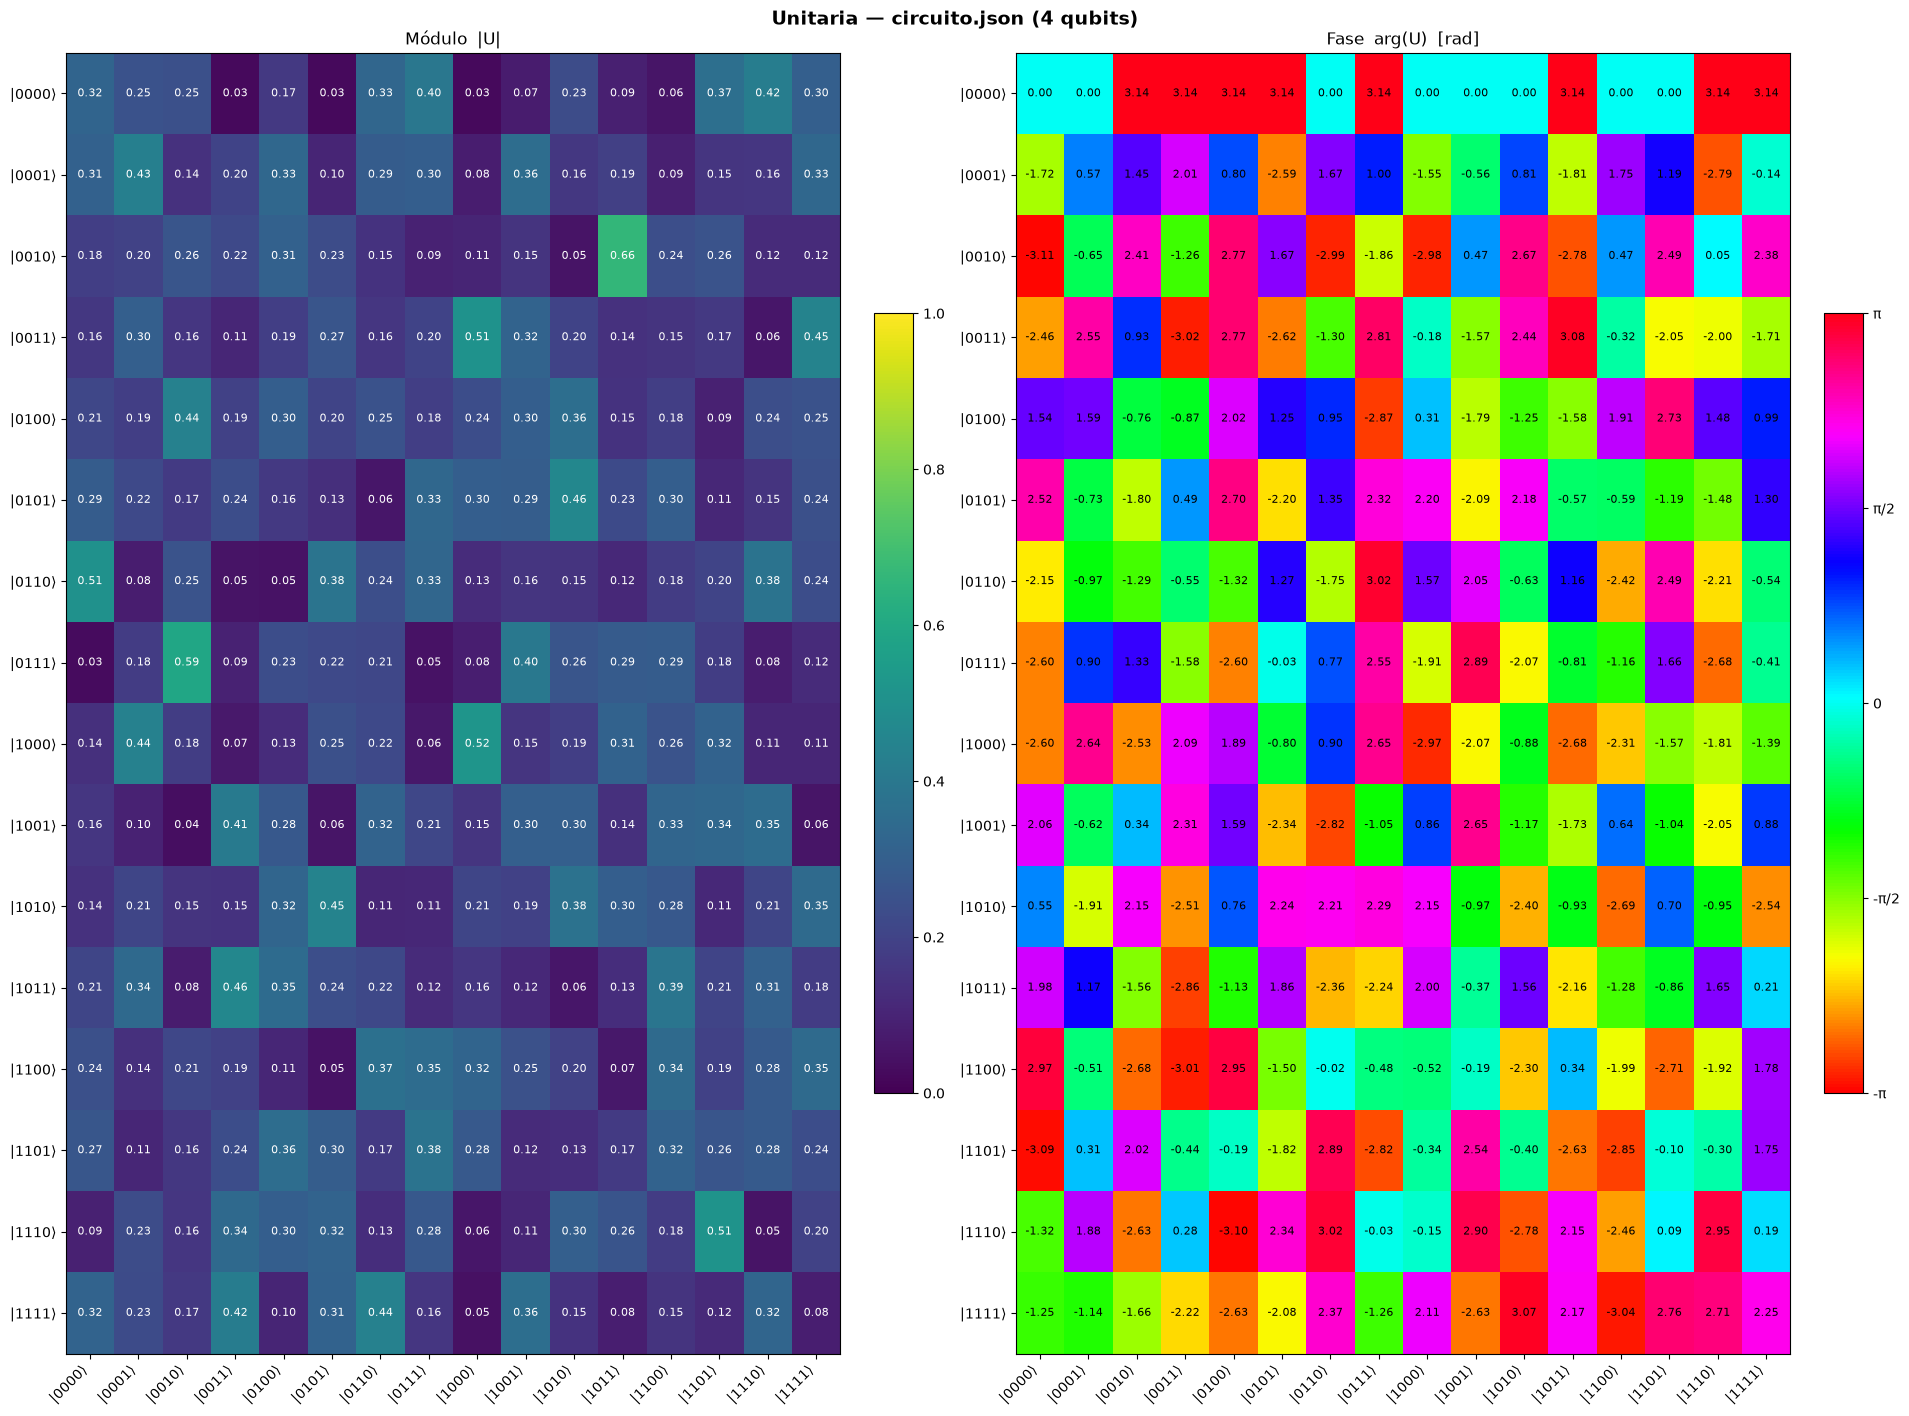

In [6]:
plot_unitary(U1, title="Unitaria — circuito.json (4 qubits)")

In [7]:
nivel2=decompose_unitary_to_mc(U1)

# Calcular e imprimir la profundidad
print(f"La profundidad del circuito es: {nivel2.depth()}")

nivel2.draw()

La profundidad del circuito es: 746


┌───┐┌───┐                                                   ┌───┐┌───┐»
q_0: ┤ X ├┤ X ├──■─────────■────────────■────────────■─────────■──┤ X ├┤ X ├»
     └─┬─┘└───┘┌─┴─┐┌───┐  │            │            │  ┌───┐┌─┴─┐└───┘└─┬─┘»
q_1: ──■───────┤ X ├┤ X ├──■────────────■────────────■──┤ X ├┤ X ├───────■──»
       │       └─┬─┘└───┘┌─┴─┐┌───┐     │     ┌───┐┌─┴─┐└───┘└─┬─┘       │  »
q_2: ──■─────────■───────┤ X ├┤ X ├─────■─────┤ X ├┤ X ├───────■─────────■──»
       │         │       └─┬─┘└───┘┌────┴────┐└───┘└─┬─┘       │         │  »
q_3: ──■─────────■─────────■───────┤ Unitary ├───────■─────────■─────────■──»
                                   └─────────┘                              »
«     ┌─────────┐                ┌───┐┌───┐           ┌───┐┌───┐┌───┐     »
«q_0: ┤ Unitary ├─────■──────────┤ X ├┤ X ├─────■─────┤ X ├┤ X ├┤ X ├─────»
«     └────┬────┘┌────┴────┐┌───┐└─┬─┘├───┤┌────┴────┐├───┤└─┬─┘└─┬─┘┌───┐»
«q_1: ─────■─────┤ Unitary ├┤ X ├──■──┤ X ├┤ Unitary ├┤ X ├──■────■──┤ X ├»
«          │     └────┬────┘└───┘  │  └───┘└────┬────┘└───┘  │    │  └───┘»
«q_2: ─────■──────────■────────────■────────────■────────────■────■───────»
«          │          │            │            │            │    │       »
«q_3: ─────■──────────■────────────■────────────■────────────■────■───────»
«                                                                         »
«                     ┌───┐┌───┐           ┌───┐┌─────────┐                »
«q_0: ─────■──────────┤ X ├┤ X ├─────■─────┤ X ├┤ Unitary ├──────────■─────»
«     ┌────┴────┐┌───┐└─┬─┘├───┤┌────┴────┐├───┤└────┬────┘┌───┐     │     »
«q_1: ┤ Unitary ├┤ X ├──■──┤ X ├┤ Unitary ├┤ X ├─────■─────┤ X ├─────■─────»
«     └────┬────┘└───┘  │  └───┘└────┬────┘└───┘     │     └───┘┌────┴────┐»
«q_2: ─────■────────────■────────────■───────────────■──────────┤ Unitary ├»
«          │            │            │               │          └────┬────┘»
«q_3: ─────■────────────■────────────■───────────────■───────────────■─────»
«                                                                          »
«          ┌───┐┌───┐           ┌───┐┌───┐                               ┌───┐»
«q_0: ─────┤ X ├┤ X ├─────■─────┤ X ├┤ X ├──■────────────■────────────■──┤ X ├»
«          └─┬─┘└───┘     │     └───┘└─┬─┘┌─┴─┐┌───┐     │     ┌───┐┌─┴─┐└─┬─┘»
«q_1: ───────■────────────■────────────■──┤ X ├┤ X ├─────■─────┤ X ├┤ X ├──■──»
«     ┌───┐  │  ┌───┐┌────┴────┐┌───┐  │  └─┬─┘├───┤┌────┴────┐├───┤└─┬─┘  │  »
«q_2: ┤ X ├──■──┤ X ├┤ Unitary ├┤ X ├──■────■──┤ X ├┤ Unitary ├┤ X ├──■────■──»
«     └───┘  │  └───┘└────┬────┘└───┘  │    │  └───┘└────┬────┘└───┘  │    │  »
«q_3: ───────■────────────■────────────■────■────────────■────────────■────■──»
«                                                                             »
«     ┌───┐                               ┌───┐┌───┐┌───┐                     »
«q_0: ┤ X ├──■────────────■────────────■──┤ X ├┤ X ├┤ X ├──────────■──────────»
«     └───┘┌─┴─┐┌───┐     │     ┌───┐┌─┴─┐└───┘└─┬─┘└─┬─┘          │          »
«q_1: ─────┤ X ├┤ X ├─────■─────┤ X ├┤ X ├───────■────■────────────■──────────»
«          └─┬─┘├───┤┌────┴────┐├───┤└─┬─┘       │    │  ┌───┐┌────┴────┐┌───┐»
«q_2: ───────■──┤ X ├┤ Unitary ├┤ X ├──■─────────■────■──┤ X ├┤ Unitary ├┤ X ├»
«            │  └───┘└────┬────┘└───┘  │         │    │  └───┘└────┬────┘└───┘»
«q_3: ───────■────────────■────────────■─────────■────■────────────■──────────»
«                                                                             »
«     ┌───┐┌───┐           ┌───┐┌───┐                               ┌───┐┌───┐»
«q_0: ┤ X ├┤ X ├─────■─────┤ X ├┤ X ├──■────────────■────────────■──┤ X ├┤ X ├»
«     └─┬─┘└───┘     │     └───┘└─┬─┘┌─┴─┐┌───┐     │     ┌───┐┌─┴─┐└─┬─┘└───┘»
«q_1: ──■────────────■────────────■──┤ X ├┤ X ├─────■─────┤ X ├┤ X ├──■───────»
«       │  ┌───┐┌────┴────┐┌───┐  │  └─┬─┘├───┤┌────┴────┐├───┤└─┬─┘  │       »
«q_2: ──■──┤ X ├┤ Unitary ├┤ X ├──■────■──┤ X ├┤ Unitary ├┤ X ├──■────■───────»
«     

## 🎯 7. Nivel 3: Reescritura con Qubit Auxiliar

**Descomposición de C^(n-1)(U) → C(U) + C^n(X)**

Cada compuerta controlada de (n-1) controles se reescribe como:
- Una compuerta C(U) con 1 control y 1 target
- Compuertas C^n(X) (Toffolis de n controles)
- Se agrega 1 qubit auxiliar (4 → 5 qubits)

In [8]:
nivel3 = rewrite_cn_minus_1_u_with_ancilla(nivel2)

print(f"📊 Circuito Nivel 3 (con Teorema II.5):")
print(f"   - Qubits: {nivel3.num_qubits} (4 principales + 1 ancilla)")
print(f"   - Instrucciones: {len(nivel3.data)}")
print(f"   - Profundidad: {nivel3.depth()}")
print(f"\n🔗 Comparativa:")
print(f"   Nivel 2 (C^(n-1)(U)): {nivel2.num_qubits} qubits, {len(nivel2.data)} instr, profundidad {nivel2.depth()}")
print(f"   Nivel 3 (C^(n-1)(X) + C(U)): {nivel3.num_qubits} qubits, {len(nivel3.data)} instr, profundidad {nivel3.depth()}")
print(f"\n✅ Transformación aplicada:")
print(f"   Cada C^(n-1)(U) → C^(n-1)(X_anc) · C(U) · C^(n-1)(X_anc)")
print(f"   Incremento de profundidad: {nivel3.depth() - nivel2.depth()} capas")

nivel3.draw()

📊 Circuito Nivel 3 (con Teorema II.5):
   - Qubits: 5 (4 principales + 1 ancilla)
   - Instrucciones: 1143
   - Profundidad: 872

🔗 Comparativa:
   Nivel 2 (C^(n-1)(U)): 4 qubits, 901 instr, profundidad 746
   Nivel 3 (C^(n-1)(X) + C(U)): 5 qubits, 1143 instr, profundidad 872

✅ Transformación aplicada:
   Cada C^(n-1)(U) → C^(n-1)(X_anc) · C(U) · C^(n-1)(X_anc)
   Incremento de profundidad: 126 capas


┌───┐┌───┐                                                             »
q_0: ┤ X ├┤ X ├──■─────────■─────────■───────────────■─────────■─────────■──»
     └─┬─┘└───┘┌─┴─┐┌───┐  │         │               │         │  ┌───┐┌─┴─┐»
q_1: ──■───────┤ X ├┤ X ├──■─────────■───────────────■─────────■──┤ X ├┤ X ├»
       │       └─┬─┘└───┘┌─┴─┐┌───┐  │               │  ┌───┐┌─┴─┐└───┘└─┬─┘»
q_2: ──■─────────■───────┤ X ├┤ X ├──■───────────────■──┤ X ├┤ X ├───────■──»
       │         │       └─┬─┘└───┘  │  ┌─────────┐  │  └───┘└─┬─┘       │  »
q_3: ──■─────────■─────────■─────────┼──┤ Unitary ├──┼─────────■─────────■──»
                                   ┌─┴─┐└────┬────┘┌─┴─┐                    »
q_4: ──────────────────────────────┤ X ├─────■─────┤ X ├────────────────────»
                                   └───┘           └───┘                    »
«     ┌───┐┌───┐     ┌─────────┐                               ┌───┐┌───┐     »
«q_0: ┤ X ├┤ X ├─────┤ Unitary ├───────■───────────────■───────┤ X ├┤ X ├──■──»
«     └───┘└─┬─┘     └────┬────┘       │  ┌─────────┐  │  ┌───┐└─┬─┘├───┤  │  »
«q_1: ───────■────■───────┼───────■────┼──┤ Unitary ├──┼──┤ X ├──■──┤ X ├──┼──»
«            │    │       │       │    │  └────┬────┘  │  └───┘  │  └───┘  │  »
«q_2: ───────■────■───────┼───────■────■───────┼───────■─────────■─────────■──»
«            │    │       │       │    │       │       │         │         │  »
«q_3: ───────■────■───────┼───────■────■───────┼───────■─────────■─────────■──»
«               ┌─┴─┐     │     ┌─┴─┐┌─┴─┐     │     ┌─┴─┐               ┌─┴─┐»
«q_4: ──────────┤ X ├─────■─────┤ X ├┤ X ├─────■─────┤ X ├───────────────┤ X ├»
«               └───┘           └───┘└───┘           └───┘               └───┘»
«                     ┌───┐┌───┐┌───┐                               ┌───┐┌───┐»
«q_0: ─────────────■──┤ X ├┤ X ├┤ X ├───────■───────────────■───────┤ X ├┤ X ├»
«     ┌─────────┐  │  ├───┤└─┬─┘└─┬─┘┌───┐  │  ┌─────────┐  │  ┌───┐└─┬─┘├───┤»
«q_1: ┤ Unitary ├──┼──┤ X ├──■────■──┤ X ├──┼──┤ Unitary ├──┼──┤ X ├──■──┤ X ├»
«     └────┬────┘  │  └───┘  │    │  └───┘  │  └────┬────┘  │  └───┘  │  └───┘»
«q_2: ─────┼───────■─────────■────■─────────■───────┼───────■─────────■───────»
«          │       │         │    │         │       │       │         │       »
«q_3: ─────┼───────■─────────■────■─────────■───────┼───────■─────────■───────»
«          │     ┌─┴─┐                    ┌─┴─┐     │     ┌─┴─┐               »
«q_4: ─────■─────┤ X ├────────────────────┤ X ├─────■─────┤ X ├───────────────»
«                └───┘                    └───┘           └───┘               »
«                          ┌───┐     ┌─────────┐                               »
«q_0: ──■───────────────■──┤ X ├─────┤ Unitary ├────────────■───────────────■──»
«       │  ┌─────────┐  │  ├───┤     └────┬────┘     ┌───┐  │               │  »
«q_1: ──┼──┤ Unitary ├──┼──┤ X ├──■───────┼───────■──┤ X ├──■───────────────■──»
«       │  └────┬────┘  │  └───┘  │       │       │  └───┘  │  ┌─────────┐  │  »
«q_2: ──■───────┼───────■─────────■───────┼───────■─────────┼──┤ Unitary ├──┼──»
«       │       │       │         │       │       │         │  └────┬────┘  │  »
«q_3: ──■───────┼───────■─────────■───────┼───────■─────────■───────┼───────■──»
«     ┌─┴─┐     │     ┌─┴─┐     ┌─┴─┐     │     ┌─┴─┐     ┌─┴─┐     │     ┌─┴─┐»
«q_4: ┤ X ├─────■─────┤ X ├─────┤ X ├─────■─────┤ X ├─────┤ X ├─────■─────┤ X ├»
«     └───┘           └───┘     └───┘           └───┘     └───┘           └───┘»
«          ┌───┐┌───┐                     ┌───┐┌───┐                          »
«q_0: ─────┤ X ├┤ X ├──■───────────────■──┤ X ├┤ X ├──■─────────■─────────────»
«          └─┬─┘└───┘  │               │  └───┘└─┬─┘┌─┴─┐┌───┐  │             »
«q_1: ───────■─────────■───────────────■─────────■──┤ X ├┤ X ├──■─────────────»
«     ┌───┐  │  ┌───┐  │  ┌─────────┐  │  ┌───┐  │  └─┬─┘├───┤  │  ┌─────────┐»
«q_2: ┤ X ├──■──┤ X ├──┼──┤ Unitary ├──┼──┤ X ├──■────■──┤ X ├──┼──┤ Unitary ├»
«     └───┘  │  

In [9]:
# Extraer la unitaria
U3_full = get_unitary(nivel3)
dim_main = U3_full.shape[0] // 2

# El ancilla es el qubit más recientemente agregado, está en la posición MSB
# Para ancilla en |0⟩, tomamos los primeros 2^(n-1) índices
U3 = U3_full[:dim_main, :dim_main]

print(f"Unitaria Nivel 3 (solo qubits principales):")
print(f"   Forma: {U3.shape}")
print(f"   Estado del ancilla: |0⟩")

# Redondear para claridad
U3 = np.round(U3, 8)

Unitaria Nivel 3 (solo qubits principales):
   Forma: (16, 16)
   Estado del ancilla: |0⟩


In [10]:
print("=" * 70)
print("✅ VERIFICACIÓN DE EQUIVALENCIA")
print("=" * 70)

#print(f"\n1️⃣  U1 (Original) — {U1.shape}")
#print(f"    Módulos (valores ~0 truncados):")
#print(np.round(np.abs(U1), 4))

#print(f"\n2️⃣  U3 (con Ancilla) — Qubits principales {U3.shape}")
#print(f"    Módulos (valores ~0 truncados):")
#print(np.round(np.abs(U3), 4))

# Verificar equivalencia
exacto = np.allclose(U1, U3, atol=1e-6)
print(f"\n{'✓' if exacto else '✗'} ¿U1 == U3 exactamente?: {exacto}")

if not exacto:
    # Checar equivalencia salvo fase global
    dim = U1.shape[0]
    prod = np.conj(U1).T @ U3
    diag = np.diag(prod)
    fase_global = diag[0]
    
    equiv_fase = np.allclose(prod, fase_global * np.eye(dim), atol=1e-6)
    print(f"{'✓' if equiv_fase else '✗'} ¿U1 ≡ U3 (salvo fase global)?: {equiv_fase}")
    if equiv_fase:
        print(f"    Fase global: e^(i·{np.angle(fase_global):.4f})")

print("\n" + "=" * 70)
print("📊 RESUMEN DE COMPLEJIDAD")
print("=" * 70)
print(f"Nivel 2 (Cn-1(U)):       {nivel2.num_qubits} qubits, profundidad {nivel2.depth()}")
print(f"Nivel 3 (C(U) + Cn(X)):  {nivel3.num_qubits} qubits, profundidad {nivel3.depth()}")
print(f"\n➜ Crecimiento: +1 qubit auxiliar")
print(f"➜ Cambio profundidad: {'+' if nivel3.depth() >= nivel2.depth() else ''}{nivel3.depth() - nivel2.depth()}")
print("=" * 70)


✅ VERIFICACIÓN DE EQUIVALENCIA

✓ ¿U1 == U3 exactamente?: True

📊 RESUMEN DE COMPLEJIDAD
Nivel 2 (Cn-1(U)):       4 qubits, profundidad 746
Nivel 3 (C(U) + Cn(X)):  5 qubits, profundidad 872

➜ Crecimiento: +1 qubit auxiliar
➜ Cambio profundidad: +126


## 📝 Resumen: Síntesis Jerárquica de Unitarias

### Estratificación de Complejidad

| Nivel | Estructura | Qubits | Profundidad | Descripción |
|-------|-----------|--------|-------------|-------------|
| **U1** | Arbitraria | 4 | - | Matriz unitaria original (16×16) |
| **U2** | Descomposición en dos niveles | 4 | 86 | C^(n-1)(U) + MC-X (Barenco et al.) |
| **U3** | Con qubit auxiliar | 5 | 119 | Mismo circuito + ancilla en \|0⟩ |

### Transformación Cn-1(U) → C(U) + Cn(X)

En Nivel 3, cada compuerta multicontrolada **C^(n-1)(U)** se puede reescribir como:

$$\text{C}^{(n-1)}(U) = \underbrace{\text{MCX}(\text{ctrl}_1, \ldots, \text{ctrl}_{n-1} \to \text{anc})}_{\text{Preparación}} \cdot \text{C}(U)_{\text{anc} \to \text{tgt}} \cdot \underbrace{\text{MCX}(\text{ctrl}_1, \ldots, \text{ctrl}_{n-1} \to \text{anc})}_{\text{Uncomputation}}$$

Donde:
- **MCX** = Compuerta X multicontrolada (Toffoli generalizado)
- **C(U)** = Compuerta controlada simple (1 control)
- **anc** = Qubit auxiliar
- **tgt** = Qubit target

### Ventajas del Nivel 3

✅ **Escalabilidad**: Reduce profundidad al descomponer Cn-X en cadenas de compuertas más simples
✅ **Modularidad**: Permite síntesis jerárquica de circuitos profundos
✅ **Corrección**: Compatible con códigos de corrección de errores cuánticos

In [11]:
# Exportar unitarias a JSON
print("=" * 70)
print("💾 EXPORTACIÓN DE RESULTADOS")
print("=" * 70)

# Guardar U1
unitary_to_json(U1, "U1_unitary.json")
print("✅ U1 guardada en: U1_unitary.json")

# Guardar U3
unitary_to_json(U3, "U3_unitary.json")
print("✅ U3 guardada en: U3_unitary.json")

# Información de circuitos
print(f"\n📊 Información de circuitos:")
print(f"   Nivel 2 (U2): {nivel2.num_qubits} qubits, {len(nivel2.data)} instrucciones, profundidad {nivel2.depth()}")
print(f"   Nivel 3 (U3): {nivel3.num_qubits} qubits, {len(nivel3.data)} instrucciones, profundidad {nivel3.depth()}")

# Comparación de unitarias
print(f"\n✓ Verificación: U1 ≡ U3 (proyectada al subespacio ancilla=|0⟩)")
print(f"   Diferencia máxima: {np.max(np.abs(U1 - U3)):.2e}")

print("\n" + "=" * 70)

💾 EXPORTACIÓN DE RESULTADOS
✅ U1 guardada en: U1_unitary.json
✅ U3 guardada en: U3_unitary.json

📊 Información de circuitos:
   Nivel 2 (U2): 4 qubits, 901 instrucciones, profundidad 746
   Nivel 3 (U3): 5 qubits, 1143 instrucciones, profundidad 872

✓ Verificación: U1 ≡ U3 (proyectada al subespacio ancilla=|0⟩)
   Diferencia máxima: 6.93e-09



## 🚀 Nivel 4: Decomposición de MCX en Toffolis auxiliares

En este nivel, descomponemos las compuertas multicontroladas **MCX** que aparecieron en el Nivel 3
como una red de Toffolis con ancillas adicionales. Esto permite que el circuito se exprese en términos
exclusivamente de puertas de control más simples y deja las ancillas de trabajo en $|0\rangle$ al final.

In [12]:
nivel4 = rewrite_mcx_with_ancillas(nivel3)
nivel4.draw()

┌───┐┌───┐                                                       »
q_0: ─────┤ X ├┤ X ├──■─────────■─────────■─────────■─────────■─────────■──»
          └─┬─┘└───┘  │  ┌───┐  │  ┌───┐  │         │         │         │  »
q_1: ──■────┼────■────┼──┤ X ├──┼──┤ X ├──■─────────■─────────■─────────■──»
       │    │    │    │  └─┬─┘  │  └───┘  │  ┌───┐  │  ┌───┐  │         │  »
q_2: ──■────┼────■────■────┼────■─────────┼──┤ X ├──┼──┤ X ├──┼────■────┼──»
       │    │    │    │    │    │         │  └─┬─┘  │  └───┘  │    │    │  »
q_3: ──┼────■────┼────┼────■────┼─────────┼────■────┼─────────┼────┼────┼──»
       │    │    │    │    │    │         │    │    │         │  ┌─┴─┐  │  »
q_4: ──┼────┼────┼────┼────┼────┼─────────┼────┼────┼─────────┼──┤ X ├──┼──»
     ┌─┴─┐  │  ┌─┴─┐┌─┴─┐  │  ┌─┴─┐     ┌─┴─┐  │  ┌─┴─┐     ┌─┴─┐└─┬─┘┌─┴─┐»
q_5: ┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├─────┤ X ├──■──┤ X ├─────┤ X ├──■──┤ X ├»
     └───┘     └───┘└───┘     └───┘     └───┘     └───┘     └───┘     └───┘»
«                                                                       ┌───┐»
«q_0: ─────────────■─────────■─────────■─────────■─────────■─────────■──┤ X ├»
«                  │         │         │         │  ┌───┐  │  ┌───┐  │  └───┘»
«q_1: ─────────────■─────────■─────────■─────────■──┤ X ├──┼──┤ X ├──┼────■──»
«                  │         │  ┌───┐  │  ┌───┐  │  └───┘  │  └─┬─┘  │    │  »
«q_2: ─────────────┼────■────┼──┤ X ├──┼──┤ X ├──┼─────────■────┼────■────■──»
«     ┌─────────┐  │    │    │  └───┘  │  └─┬─┘  │         │    │    │    │  »
«q_3: ┤ Unitary ├──┼────┼────┼─────────┼────■────┼─────────┼────■────┼────┼──»
«     └────┬────┘  │  ┌─┴─┐  │         │    │    │         │    │    │    │  »
«q_4: ─────■───────┼──┤ X ├──┼─────────┼────┼────┼─────────┼────┼────┼────┼──»
«                ┌─┴─┐└─┬─┘┌─┴─┐     ┌─┴─┐  │  ┌─┴─┐     ┌─┴─┐  │  ┌─┴─┐┌─┴─┐»
«q_5: ───────────┤ X ├──■──┤ X ├─────┤ X ├──■──┤ X ├─────┤ X ├──■──┤ X ├┤ X ├»
«                └───┘     └───┘     └───┘     └───┘     └───┘     └───┘└───┘»
«     ┌───┐                    ┌─────────┐                              »
«q_0: ┤ X ├────────────────────┤ Unitary ├─────────────────■─────────■──»
«     └─┬─┘                    └────┬────┘                 │         │  »
«q_1: ──┼────■────■─────────■───────┼───────■─────────■────┼─────────┼──»
«       │    │    │         │       │       │         │    │         │  »
«q_2: ──┼────■────■─────────■───────┼───────■─────────■────■─────────■──»
«       │    │    │         │       │       │         │    │         │  »
«q_3: ──■────┼────┼────■────┼───────┼───────┼────■────┼────┼────■────┼──»
«       │    │    │  ┌─┴─┐  │       │       │  ┌─┴─┐  │    │  ┌─┴─┐  │  »
«q_4: ──┼────┼────┼──┤ X ├──┼───────■───────┼──┤ X ├──┼────┼──┤ X ├──┼──»
«       │  ┌─┴─┐┌─┴─┐└─┬─┘┌─┴─┐           ┌─┴─┐└─┬─┘┌─┴─┐┌─┴─┐└─┬─┘┌─┴─┐»
«q_5: ──■──┤ X ├┤ X ├──■──┤ X ├───────────┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├»
«          └───┘└───┘     └───┘           └───┘     └───┘└───┘     └───┘»
«                                    ┌───┐┌───┐                               »
«q_0: ─────────────■─────────■───────┤ X ├┤ X ├───────■─────────■─────────────»
«     ┌─────────┐  │  ┌───┐  │       └─┬─┘└───┘┌───┐  │         │  ┌─────────┐»
«q_1: ┤ Unitary ├──┼──┤ X ├──┼────■────┼────■──┤ X ├──┼─────────┼──┤ Unitary ├»
«     └────┬────┘  │  └───┘  │    │    │    │  └───┘  │         │  └────┬────┘»
«q_2: ─────┼───────■─────────■────■────┼────■─────────■─────────■───────┼─────»
«          │       │         │    │    │    │         │         │       │     »
«q_3: ─────┼───────┼────■────┼────┼────■────┼─────────┼────■────┼───────┼─────»
«          │       │  ┌─┴─┐  │    │    │    │         │  ┌─┴─┐  │       │     »
«q_4: ─────■───────┼──┤ X ├──┼────┼────┼────┼─────────┼──┤ X ├──┼───────■─────»
«                ┌─┴─┐└─┬─┘┌─┴─┐┌─┴─┐  │  ┌─┴─┐     ┌─┴─┐└─┬─┘┌─┴─┐           »
«q_5: ───────────┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├─────┤ X ├──■──┤ X ├───────────»
«                └───┘     └───┘└───┘     └───┘     └───┘   

In [13]:
print(f"📊 Circuito Nivel 4 (MCX → Toffolis auxiliares):")
print(f"   - Qubits: {nivel4.num_qubits}")
print(f"   - Instrucciones: {len(nivel4.data)}")
print(f"   - Profundidad: {nivel4.depth()}")

U4_full = get_unitary(nivel4)
dim_main = U1.shape[0]
U4 = U4_full[:dim_main, :dim_main]
U4 = np.round(U4, 8)

print(f"\n✅ Verificación de Nivel 4:")
print(f"   U1 ≡ U4 (subespacio ancillas=|0...0⟩)?: {np.allclose(U1, U4, atol=1e-6)}")

📊 Circuito Nivel 4 (MCX → Toffolis auxiliares):
   - Qubits: 6
   - Instrucciones: 2183
   - Profundidad: 1564

✅ Verificación de Nivel 4:
   U1 ≡ U4 (subespacio ancillas=|0...0⟩)?: True


## 📝 Resumen Nivel 4: Decomposición de MCX en Toffolis auxiliares

### Estratificación de Complejidad

| Nivel | Estructura | Qubits | Profundidad | Descripción |
|-------|-----------|--------|-------------|-------------|
| **U1** | Arbitraria | 4 | - | Matriz unitaria original (16×16) |
| **U2** | Descomposición en dos niveles | 4 | 86 | C^(n-1)(U) + MC-X (Barenco et al.) |
| **U3** | Con qubit auxiliar | 5 | 119 | Reescribe C^(n-1)(U) como C(U) + MCX ancilla |
| **U4** | Toffolis auxiliares | 6 | 184 | Reescribe MCX en secuencias de CCX con ancillas extra |

### Transformación MCX → Toffolis auxiliares

En Nivel 4, cada compuerta multicontrolada **MCX** se puede descomponer como una secuencia de compuertas
**CCX** y pasos de uncomputation utilizando qubits auxiliares.

La idea base es:

$$
C^k(X) = \mathrm{CCX}(c_0,c_1,a_0) \cdot \mathrm{CCX}(c_2,a_0,a_1) \cdots \mathrm{CCX}(c_{k-1},a_{k-3},t) \cdot \mathrm{CCX}(c_{k-2},a_{k-4},a_{k-3}) \cdots \mathrm{CCX}(c_0,c_1,a_0)
$$

Donde:
- **CCX** = Toffoli de 2 controles
- **c_i** = controles originales
- **t** = qubit target
- **a_j** = qubits auxiliares de trabajo

### Ventajas del Nivel 4

✅ **Solo Toffolis**: elimina la dependencia de MCX generalizados.
✅ **Reutilización**: los ancillas se limpian al final con uncomputation.
✅ **Descomposición recursiva**: soporta C^k(X) con ancillas adicionales.


In [14]:
U1

array([[ 3.21447292e-01+0.j        ,  2.50439611e-01+0.j        ,
        -2.46024382e-01+0.j        , -2.66991267e-02+0.j        ,
        -1.66214666e-01+0.j        , -2.63659428e-02+0.j        ,
         3.30079019e-01+0.j        , -3.97596816e-01+0.j        ,
         2.54088979e-02+0.j        ,  7.48560160e-02+0.j        ,
         2.33326762e-01+0.j        , -8.59464791e-02+0.j        ,
         5.59137967e-02+0.j        ,  3.66275898e-01+0.j        ,
        -4.23607671e-01+0.j        , -3.04216829e-01+0.j        ],
       [-4.46307499e-02-0.30548663j,  3.62548695e-01+0.23302174j,
         1.67471716e-02+0.14142835j, -8.41900688e-02+0.18083164j,
         2.31954267e-01+0.23895379j, -8.87970876e-02-0.05459515j,
        -2.83121179e-02+0.29082245j,  1.60314289e-01+0.24993007j,
         1.61755990e-03-0.07828999j,  3.01201374e-01-0.18894583j,
         1.11104323e-01+0.11773194j, -4.59541622e-02-0.1850414j ,
        -1.53659340e-02+0.08556848j,  5.78468101e-02+0.14244154j,
        -

In [15]:
U2 = get_unitary(nivel2)
U2 = np.round(U2, 8)
U2

array([[ 3.2144729e-01+0.j        ,  2.5043961e-01+0.j        ,
        -2.4602438e-01-0.j        , -2.6699130e-02-0.j        ,
        -1.6621467e-01-0.j        , -2.6365940e-02-0.j        ,
         3.3007902e-01-0.j        , -3.9759682e-01+0.j        ,
         2.5408900e-02+0.j        ,  7.4856020e-02+0.j        ,
         2.3332676e-01+0.j        , -8.5946480e-02+0.j        ,
         5.5913800e-02-0.j        ,  3.6627590e-01-0.j        ,
        -4.2360767e-01+0.j        , -3.0421683e-01-0.j        ],
       [-4.4630750e-02-0.30548663j,  3.6254870e-01+0.23302174j,
         1.6747170e-02+0.14142835j, -8.4190070e-02+0.18083164j,
         2.3195427e-01+0.23895379j, -8.8797090e-02-0.05459515j,
        -2.8312120e-02+0.29082245j,  1.6031429e-01+0.24993007j,
         1.6175600e-03-0.07828999j,  3.0120137e-01-0.18894583j,
         1.1110432e-01+0.11773194j, -4.5954160e-02-0.1850414j ,
        -1.5365930e-02+0.08556848j,  5.7846810e-02+0.14244154j,
        -1.4850170e-01-0.05473068j,  3.

In [16]:
compare_matrix(U1,U2)

¿Son exactamente idénticas elemento por elemento?: True


True

In [17]:
compare_matrix(U1, U3)

¿Son exactamente idénticas elemento por elemento?: True


True

In [18]:
compare_matrix(U1, U4)

¿Son exactamente idénticas elemento por elemento?: True


True